In [8]:
# 1. SETUP ÉS ADATBETÖLTÉS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Stílus beállítás
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Adatbeolvasás
df = pd.read_csv("data/ml_input.csv")


MISSING VALUES ELEMZÉS

Összesen 52 oszlop tartalmaz missing value-kat:

                         Missing_Count  Missing_Pct
diff_last_3_winrate                 69        57.50
away_avg_h2h_winrate                57        47.50
away_last_5_winrate                 53        44.17
away_avg_map_pickrate               53        44.17
away_last_3_winrate                 53        44.17
away_current_streak                 53        44.17
away_avg_rating                     53        44.17
away_avg_rating_std                 53        44.17
away_avg_adr                        53        44.17
away_avg_adr_std                    53        44.17
away_avg_swing                      53        44.17
away_avg_swing_std                  53        44.17
away_avg_maps_total                 53        44.17
away_avg_map_winrate                53        44.17
away_avg_map_score_diff             53        44.17

→ Home team features: 52 oszlop hiányos
→ Away team features: 52 oszlop hiányos
→ Teljes soro

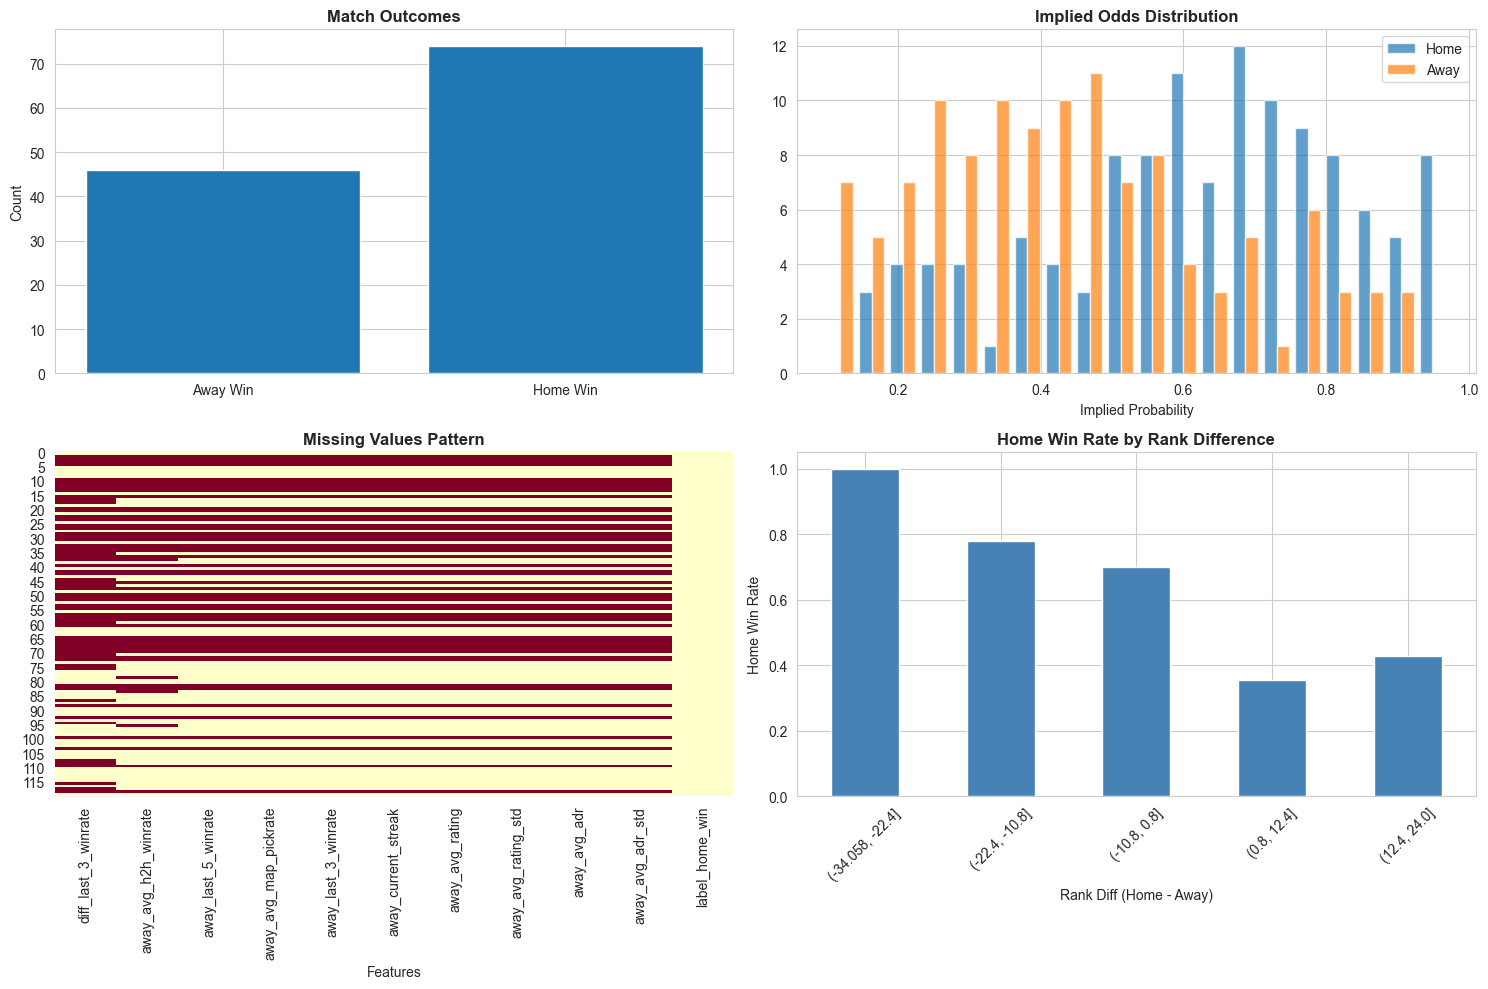


EDA KÉSZ


In [10]:
# 2. EXPLORATÍV ADATELEMZÉS (EDA)

print("\n" + "=" * 80)
print("MISSING VALUES ELEMZÉS")
print("=" * 80)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing_Count': missing[missing > 0],
    'Missing_Pct': missing_pct[missing > 0]
}).sort_values('Missing_Pct', ascending=False)

print(f"\nÖsszesen {len(missing_df)} oszlop tartalmaz missing value-kat:\n")
print(missing_df.head(15))

print(f"\n→ Home team features: {missing_df.filter(like='home').shape[0]} oszlop hiányos")
print(f"→ Away team features: {missing_df.filter(like='away').shape[0]} oszlop hiányos")
print(f"→ Teljes sorok (nincs NULL): {df.dropna().shape[0]} / {len(df)}")

# ============================================================================
# ODDS KALIBRÁCIÓ - Mennyire pontosak a bukmékerek?
# ============================================================================

print("\n" + "=" * 80)
print("ODDS KALIBRÁCIÓ ELEMZÉS")
print("=" * 80)

df['bookmaker_pred_home'] = (df['home_implied_odds'] > df['away_implied_odds']).astype(int)
bookmaker_accuracy = (df['bookmaker_pred_home'] == df['label_home_win']).mean()

print(f"\nBukmékeri accuracy (favorite wins): {bookmaker_accuracy:.2%}")
print(f"Baseline (mindig home-ra fogadni): {df['label_home_win'].mean():.2%}")

# Odds range elemzés
print(f"\nHome odds range: {df['home_odds'].min():.2f} - {df['home_odds'].max():.2f}")
print(f"Away odds range: {df['away_odds'].min():.2f} - {df['away_odds'].max():.2f}")

# ============================================================================
# FEATURE KORRELÁCIÓ A TARGET-TEL
# ============================================================================

print("\n" + "=" * 80)
print("TOP FEATURE-ÖK KORRELÁCIÓJA A TARGET-TEL")
print("=" * 80)

# Csak numerikus oszlopok
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlations = df[numeric_cols].corrwith(df['label_home_win']).abs().sort_values(ascending=False)

print("\nLegerősebb korreláció:")
print(correlations.head(15))

# ============================================================================
# H2H ADATOK ELLENŐRZÉSE
# ============================================================================

print("\n" + "=" * 80)
print("HEAD-TO-HEAD ADATOK")
print("=" * 80)

print(f"\nH2H games eloszlás:")
print(df['H2H_games'].value_counts().head(10))
print(f"\nÁtlagos H2H games: {df['H2H_games'].mean():.2f}")
print(f"Meccsek H2H történet nélkül (0 games): {(df['H2H_games'] == 0).sum()} / {len(df)}")

# ============================================================================
# VIZUALIZÁCIÓK
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Target eloszlás
axes[0, 0].bar(['Away Win', 'Home Win'], df['label_home_win'].value_counts().sort_index())
axes[0, 0].set_title('Match Outcomes', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Count')

# 2. Implied odds eloszlás
axes[0, 1].hist([df['home_implied_odds'], df['away_implied_odds']], 
                bins=20, label=['Home', 'Away'], alpha=0.7)
axes[0, 1].set_title('Implied Odds Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Implied Probability')
axes[0, 1].legend()

# 3. Missing values heatmap (top features)
top_missing_cols = missing_df.head(10).index.tolist() + ['label_home_win']
sns.heatmap(df[top_missing_cols].isnull(), cbar=False, ax=axes[1, 0], cmap='YlOrRd')
axes[1, 0].set_title('Missing Values Pattern', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Features')

# 4. Win rate vs rank difference
df_clean = df.dropna(subset=['home_current_rank', 'away_current_rank'])
df_clean['rank_diff'] = df_clean['home_current_rank'] - df_clean['away_current_rank']
rank_bins = pd.cut(df_clean['rank_diff'], bins=5)
win_by_rank = df_clean.groupby(rank_bins)['label_home_win'].mean()
win_by_rank.plot(kind='bar', ax=axes[1, 1], color='steelblue')
axes[1, 1].set_title('Home Win Rate by Rank Difference', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Rank Diff (Home - Away)')
axes[1, 1].set_ylabel('Home Win Rate')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("EDA KÉSZ")
print("=" * 80)

In [25]:
# 3. FEATURE ENGINEERING ÉS SZŰRÉS

print("\n" + "=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)

# Dátum konverzió
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# KRITIKUS: Leakage feature-ök eltávolítása (ezeket csak a meccs után tudnánk)
leakage_cols = ['match_id', 'event_id', 'match_url', 'date', 
                'score_home', 'score_away', 'match_rounds', 'bookmaker_pred_home']
print(f"\n→ Leakage feature-ök eltávolítása: {len(leakage_cols)} oszlop")

# Új feature-ök
df['rank_diff'] = df['home_current_rank'] - df['away_current_rank']
df['odds_diff'] = df['home_odds'] - df['away_odds']
df['implied_odds_diff'] = df['home_implied_odds'] - df['away_implied_odds']
df['has_h2h_history'] = (df['H2H_games'] > 0).astype(int)

print(f"→ Új feature-ök létrehozva: rank_diff, odds_diff, implied_odds_diff, has_h2h_history")

# Feature-ök kiválasztása
feature_cols = [col for col in df.columns if col not in leakage_cols + ['label_home_win', 'team_home', 'team_away']]

print(f"\n→ Potenciális feature-ök száma: {len(feature_cols)}")

# Missing value kezelés: sorok droppolása ahol túl sok hiányzik
df_clean = df.dropna(subset=['home_odds', 'away_odds'], how='any')
print(f"→ Sorok szűrés után (mindkét csapat form data kell): {len(df_clean)} / {len(df)}")

# Maradék missing-ek imputálása (H2H és egyéb)
for col in feature_cols:
    if df_clean[col].isnull().sum() > 0:
        if 'h2h' in col.lower():
            df_clean[col].fillna(0.5, inplace=True)  # Neutral H2H
        else:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

print(f"→ Missing values imputálva")
print(f"→ Végleges dataset méret: {len(df_clean)} sor, {len(feature_cols)} feature")



FEATURE ENGINEERING

→ Leakage feature-ök eltávolítása: 8 oszlop
→ Új feature-ök létrehozva: rank_diff, odds_diff, implied_odds_diff, has_h2h_history

→ Potenciális feature-ök száma: 67
→ Sorok szűrés után (mindkét csapat form data kell): 120 / 120
→ Missing values imputálva
→ Végleges dataset méret: 120 sor, 67 feature


In [42]:
odds_features = ['implied_odds_diff', 'home_implied_odds', 'odds_diff',
                 'away_odds', 'home_odds', 'away_implied_odds']

for of in odds_features:
    t.remove(of)

print(t)

['away_current_rank', 'away_avg_h2h_winrate', 'away_avg_rating_std', 'home_current_rank', 'home_std_rank_diff', 'home_avg_rating_std', 'away_avg_swing_std', 'away_strong_opp_rank_diff']


In [43]:
# 4. TRAIN-TEST SPLIT (IDŐBELI)

print("\n" + "=" * 80)
print("TRAIN-TEST SPLIT (Időbeli)")
print("=" * 80)

# 80-20 split időrendben
split_idx = int(len(df_clean) * 0.8)
train_df = df_clean.iloc[:split_idx].copy()
test_df = df_clean.iloc[split_idx:].copy()

print(f"\nTrain: {len(train_df)} meccs ({train_df['date'].min().date()} → {train_df['date'].max().date()})")
print(f"Test:  {len(test_df)} meccs ({test_df['date'].min().date()} → {test_df['date'].max().date()})")
print(f"\nTrain home win rate: {train_df['label_home_win'].mean():.2%}")
print(f"Test home win rate:  {test_df['label_home_win'].mean():.2%}")

X_train = train_df[feature_cols]
y_train = train_df['label_home_win']
X_test = test_df[feature_cols]
y_test = test_df['label_home_win']

# ============================================================================
# FEATURE SELECTION - Top feature-ök kiválasztása
# ============================================================================

print("\n" + "=" * 80)
print("FEATURE SELECTION")
print("=" * 80)

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

# Quick Random Forest a feature importance-hez
temp_rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
temp_rf.fit(X_train, y_train)

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': temp_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 legfontosabb feature:")
print(feature_importance.head(20))

# Top 15 feature kiválasztása
top_features = feature_importance.head(15)['feature'].tolist()
odds_features = ['implied_odds_diff', 'home_implied_odds', 'odds_diff',
                 'away_odds', 'home_odds', 'away_implied_odds']

for of in odds_features:
    top_features.remove(of)
print(f"\n→ Kiválasztott {len(top_features)} feature a modellezéshez")

# Újra definiáljuk X_train és X_test-et
X_train = X_train[top_features]
X_test = X_test[top_features]

print(f"→ Új feature dimenzió: {X_train.shape[1]}")


TRAIN-TEST SPLIT (Időbeli)

Train: 96 meccs (2025-03-07 → 2025-08-02)
Test:  24 meccs (2025-08-02 → 2025-09-02)

Train home win rate: 59.38%
Test home win rate:  70.83%

FEATURE SELECTION

Top 20 legfontosabb feature:
                       feature  importance
65           implied_odds_diff    0.094372
61           home_implied_odds    0.070778
64                   odds_diff    0.062214
60                   away_odds    0.061883
59                   home_odds    0.057422
62           away_implied_odds    0.056441
63                   rank_diff    0.041009
52           away_current_rank    0.026363
30        away_avg_h2h_winrate    0.024294
32         away_avg_rating_std    0.023500
51           home_current_rank    0.022971
17          home_std_rank_diff    0.018313
7          home_avg_rating_std    0.017991
36          away_avg_swing_std    0.017458
46   away_strong_opp_rank_diff    0.016877
44         away_std_point_diff    0.015826
18         home_avg_point_diff    0.014806
23  hom

In [44]:
# 5. MODELLÉPÍTÉS

print("\n" + "=" * 80)
print("MODELLÉPÍTÉS")
print("=" * 80)

from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from sklearn.metrics import log_loss, brier_score_loss

models = {}

# 1. Logisztikus regresszió (baseline)
print("\n[1/3] Logisztikus regresszió...")
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train, y_train)
models['Logistic Regression'] = lr

# 2. Random Forest - KISEBB, kevesebb overfitting
print("[2/3] Random Forest...")
rf = RandomForestClassifier(
    n_estimators=50,      # kevesebb fa
    max_depth=5,          # sekélyebb fák
    min_samples_leaf=3,   # minimum levél méret
    random_state=42, 
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_calibrated = CalibratedClassifierCV(rf, method='sigmoid', cv=3)
rf_calibrated.fit(X_train, y_train)
models['Random Forest'] = rf_calibrated

# 3. XGBoost - konzervatívabb
print("[3/3] XGBoost...")
xgb = XGBClassifier(
    n_estimators=50,
    max_depth=3,           # sekélyebb
    learning_rate=0.05,    # lassabb tanulás
    min_child_weight=3,    # nagyobb regularizáció
    random_state=42, 
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)
xgb_calibrated = CalibratedClassifierCV(xgb, method='sigmoid', cv=3)
xgb_calibrated.fit(X_train, y_train)
models['XGBoost'] = xgb_calibrated

# Modellek értékelése (ez maradhat ugyanaz)
print("\n" + "=" * 80)
print("MODELL TELJESÍTMÉNYEK (Test Set)")
print("=" * 80)

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    acc = (y_pred == y_test).mean()
    auc = roc_auc_score(y_test, y_proba)
    logloss = log_loss(y_test, y_proba)
    brier = brier_score_loss(y_test, y_proba)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'ROC-AUC': auc,
        'Log Loss': logloss,
        'Brier Score': brier
    })
    
    print(f"\n{name}:")
    print(f"  Accuracy:    {acc:.4f}")
    print(f"  ROC-AUC:     {auc:.4f}")
    print(f"  Log Loss:    {logloss:.4f}")
    print(f"  Brier Score: {brier:.4f}")

results_df = pd.DataFrame(results)


MODELLÉPÍTÉS

[1/3] Logisztikus regresszió...
[2/3] Random Forest...
[3/3] XGBoost...

MODELL TELJESÍTMÉNYEK (Test Set)

Logistic Regression:
  Accuracy:    0.6667
  ROC-AUC:     0.6723
  Log Loss:    0.9181
  Brier Score: 0.2677

Random Forest:
  Accuracy:    0.6250
  ROC-AUC:     0.6723
  Log Loss:    0.6666
  Brier Score: 0.2381

XGBoost:
  Accuracy:    0.5833
  ROC-AUC:     0.6765
  Log Loss:    0.6489
  Brier Score: 0.2305


In [45]:
# 6. VALUE BETTING SZIMULÁCIÓ

print("\n" + "=" * 80)
print("VALUE BETTING SZIMULÁCIÓ")
print("=" * 80)

def simulate_betting_advanced(test_df, y_proba, model_name, edge_threshold=0.05, 
                               strategy='fixed', stake=10, kelly_fraction=0.1):
    """
    Value betting szimuláció többféle stratégiával.
    
    strategy: 'fixed' = fix stake, 'kelly' = Kelly kritérium
    """
    results = []
    bankroll = 1000
    
    for idx, (i, row) in enumerate(test_df.iterrows()):
        pred_home_win = y_proba[idx]
        pred_away_win = 1 - pred_home_win
        
        home_implied = row['home_implied_odds']
        away_implied = row['away_implied_odds']
        
        actual_home_win = row['label_home_win']
        
        # Value bet keresése
        bet_on = None
        bet_odds = None
        edge = 0
        
        if pred_home_win - home_implied > edge_threshold:
            bet_on = 'home'
            bet_odds = row['home_odds']
            edge = pred_home_win - home_implied
        elif pred_away_win - away_implied > edge_threshold:
            bet_on = 'away'
            bet_odds = row['away_odds']
            edge = pred_away_win - away_implied
        
        if bet_on:
            # Bet size kalkuláció
            if strategy == 'fixed':
                bet_size = stake
            elif strategy == 'kelly':
                p = pred_home_win if bet_on == 'home' else pred_away_win
                kelly_calc = (p * bet_odds - 1) / (bet_odds - 1)
                bet_size = max(0, bankroll * kelly_calc * kelly_fraction)
                bet_size = min(bet_size, stake)  # max cap
            
            # Kimenetel
            win = (bet_on == 'home' and actual_home_win == 1) or (bet_on == 'away' and actual_home_win == 0)
            profit = bet_size * (bet_odds - 1) if win else -bet_size
            bankroll += profit
            
            results.append({
                'match': f"{row['team_home']} vs {row['team_away']}",
                'bet_on': bet_on,
                'bet_size': bet_size,
                'odds': bet_odds,
                'edge': edge,
                'win': win,
                'profit': profit,
                'bankroll': bankroll
            })
    
    return pd.DataFrame(results), bankroll

# ============================================================================
# ENSEMBLE MODELL - 3 modell átlaga
# ============================================================================

print("\n" + "=" * 80)
print("ENSEMBLE MODELL (3 modell átlaga)")
print("=" * 80)

ensemble_proba = np.mean([
    models['Logistic Regression'].predict_proba(X_test)[:, 1],
    models['Random Forest'].predict_proba(X_test)[:, 1],
    models['XGBoost'].predict_proba(X_test)[:, 1]
], axis=0)

# Ensemble értékelése
ensemble_pred = (ensemble_proba > 0.5).astype(int)
ensemble_acc = (ensemble_pred == y_test).mean()
ensemble_auc = roc_auc_score(y_test, ensemble_proba)
ensemble_logloss = log_loss(y_test, ensemble_proba)
ensemble_brier = brier_score_loss(y_test, ensemble_proba)

print(f"\nEnsemble teljesítmény:")
print(f"  Accuracy:    {ensemble_acc:.4f}")
print(f"  ROC-AUC:     {ensemble_auc:.4f}")
print(f"  Log Loss:    {ensemble_logloss:.4f}")
print(f"  Brier Score: {ensemble_brier:.4f}")

# ============================================================================
# SZIMULÁCIÓ - Minden modell + Ensemble + Különböző stratégiák
# ============================================================================

strategies = [
    {'name': 'Fixed $10', 'strategy': 'fixed', 'stake': 10, 'edge': 0.0},
    {'name': 'Fixed $10 (5% edge)', 'strategy': 'fixed', 'stake': 10, 'edge': 0.05},
    {'name': '10% Kelly (cap $10)', 'strategy': 'kelly', 'stake': 10, 'kelly_fraction': 0.1, 'edge': 0.0},
    {'name': '10% Kelly (5% edge)', 'strategy': 'kelly', 'stake': 10, 'kelly_fraction': 0.1, 'edge': 0.05}
]

all_models = {
    **models,
    'Ensemble': None  # dummy, mert már van ensemble_proba
}

print("\n" + "=" * 80)
print("VALUE BETTING EREDMÉNYEK")
print("=" * 80)

summary_results = []

for model_name in all_models.keys():
    if model_name == 'Ensemble':
        y_proba_current = ensemble_proba
    else:
        y_proba_current = models[model_name].predict_proba(X_test)[:, 1]
    
    print(f"\n{'='*80}")
    print(f"MODELL: {model_name}")
    print(f"{'='*80}")
    
    for strat in strategies:
        bets_df, final_bankroll = simulate_betting_advanced(
            test_df.copy(), 
            y_proba_current, 
            model_name,
            edge_threshold=strat['edge'],
            strategy=strat['strategy'],
            stake=strat['stake'],
            kelly_fraction=strat.get('kelly_fraction', 0.1)
        )
        
        if len(bets_df) > 0:
            total_bets = len(bets_df)
            win_rate = bets_df['win'].mean()
            total_staked = bets_df['bet_size'].sum()
            total_profit = bets_df['profit'].sum()
            roi = (total_profit / total_staked) * 100 if total_staked > 0 else 0
            bankroll_change = ((final_bankroll/1000 - 1) * 100)
            
            summary_results.append({
                'Model': model_name,
                'Strategy': strat['name'],
                'Bets': total_bets,
                'Win%': win_rate * 100,
                'Total Staked': total_staked,
                'Profit': total_profit,
                'ROI%': roi,
                'Final BR': final_bankroll,
                'BR Change%': bankroll_change
            })
            
            print(f"\n  {strat['name']}:")
            print(f"    Fogadások:      {total_bets}")
            print(f"    Win rate:       {win_rate:.2%}")
            print(f"    Összes tét:     ${total_staked:.2f}")
            print(f"    Profit:         ${total_profit:.2f}")
            print(f"    ROI:            {roi:.2f}%")
            print(f"    Végső bankroll: ${final_bankroll:.2f} ({bankroll_change:+.2f}%)")
        else:
            print(f"\n  {strat['name']}: Nincs value bet")

# Summary táblázat
print("\n" + "=" * 80)
print("ÖSSZEFOGLALÓ TÁBLÁZAT")
print("=" * 80)
summary_df = pd.DataFrame(summary_results)
print(summary_df.to_string(index=False))

# Legjobb stratégia
if len(summary_df) > 0:
    best_roi = summary_df.loc[summary_df['ROI%'].idxmax()]
    best_profit = summary_df.loc[summary_df['Profit'].idxmax()]
    
    print(f"\n🏆 Legjobb ROI: {best_roi['Model']} - {best_roi['Strategy']} ({best_roi['ROI%']:.2f}%)")
    print(f"💰 Legjobb Profit: {best_profit['Model']} - {best_profit['Strategy']} (${best_profit['Profit']:.2f})")

# ============================================================================
# BASELINE összehasonlítás
# ============================================================================

print("\n" + "=" * 80)
print("BASELINE: Mindig a favoritre fogadás (fix $10 stake)")
print("=" * 80)

baseline_profit = 0
baseline_bets = 0
for _, row in test_df.iterrows():
    if row['home_implied_odds'] > row['away_implied_odds']:
        if row['label_home_win'] == 1:
            baseline_profit += 10 * (row['home_odds'] - 1)
        else:
            baseline_profit -= 10
    else:
        if row['label_home_win'] == 0:
            baseline_profit += 10 * (row['away_odds'] - 1)
        else:
            baseline_profit -= 10
    baseline_bets += 1

baseline_roi = (baseline_profit / (baseline_bets * 10)) * 100
print(f"  Fogadások száma:     {baseline_bets}")
print(f"  Összes tét:          ${baseline_bets * 10:.2f}")
print(f"  Összes profit:       ${baseline_profit:.2f}")
print(f"  ROI:                 {baseline_roi:.2f}%")
print(f"  Végső bankroll:      ${1000 + baseline_profit:.2f}")

print("\n" + "=" * 80)
print("SZIMULÁCIÓ KÉSZ!")
print("=" * 80)


VALUE BETTING SZIMULÁCIÓ

ENSEMBLE MODELL (3 modell átlaga)

Ensemble teljesítmény:
  Accuracy:    0.6250
  ROC-AUC:     0.6639
  Log Loss:    0.6645
  Brier Score: 0.2373

VALUE BETTING EREDMÉNYEK

MODELL: Logistic Regression

  Fixed $10:
    Fogadások:      21
    Win rate:       66.67%
    Összes tét:     $210.00
    Profit:         $42.00
    ROI:            20.00%
    Végső bankroll: $1042.00 (+4.20%)

  Fixed $10 (5% edge):
    Fogadások:      17
    Win rate:       64.71%
    Összes tét:     $170.00
    Profit:         $41.00
    ROI:            24.12%
    Végső bankroll: $1041.00 (+4.10%)

  10% Kelly (cap $10):
    Fogadások:      21
    Win rate:       66.67%
    Összes tét:     $209.20
    Profit:         $42.44
    ROI:            20.29%
    Végső bankroll: $1042.44 (+4.24%)

  10% Kelly (5% edge):
    Fogadások:      17
    Win rate:       64.71%
    Összes tét:     $170.00
    Profit:         $41.00
    ROI:            24.12%
    Végső bankroll: $1041.00 (+4.10%)

MODEL


VIZUALIZÁCIÓK


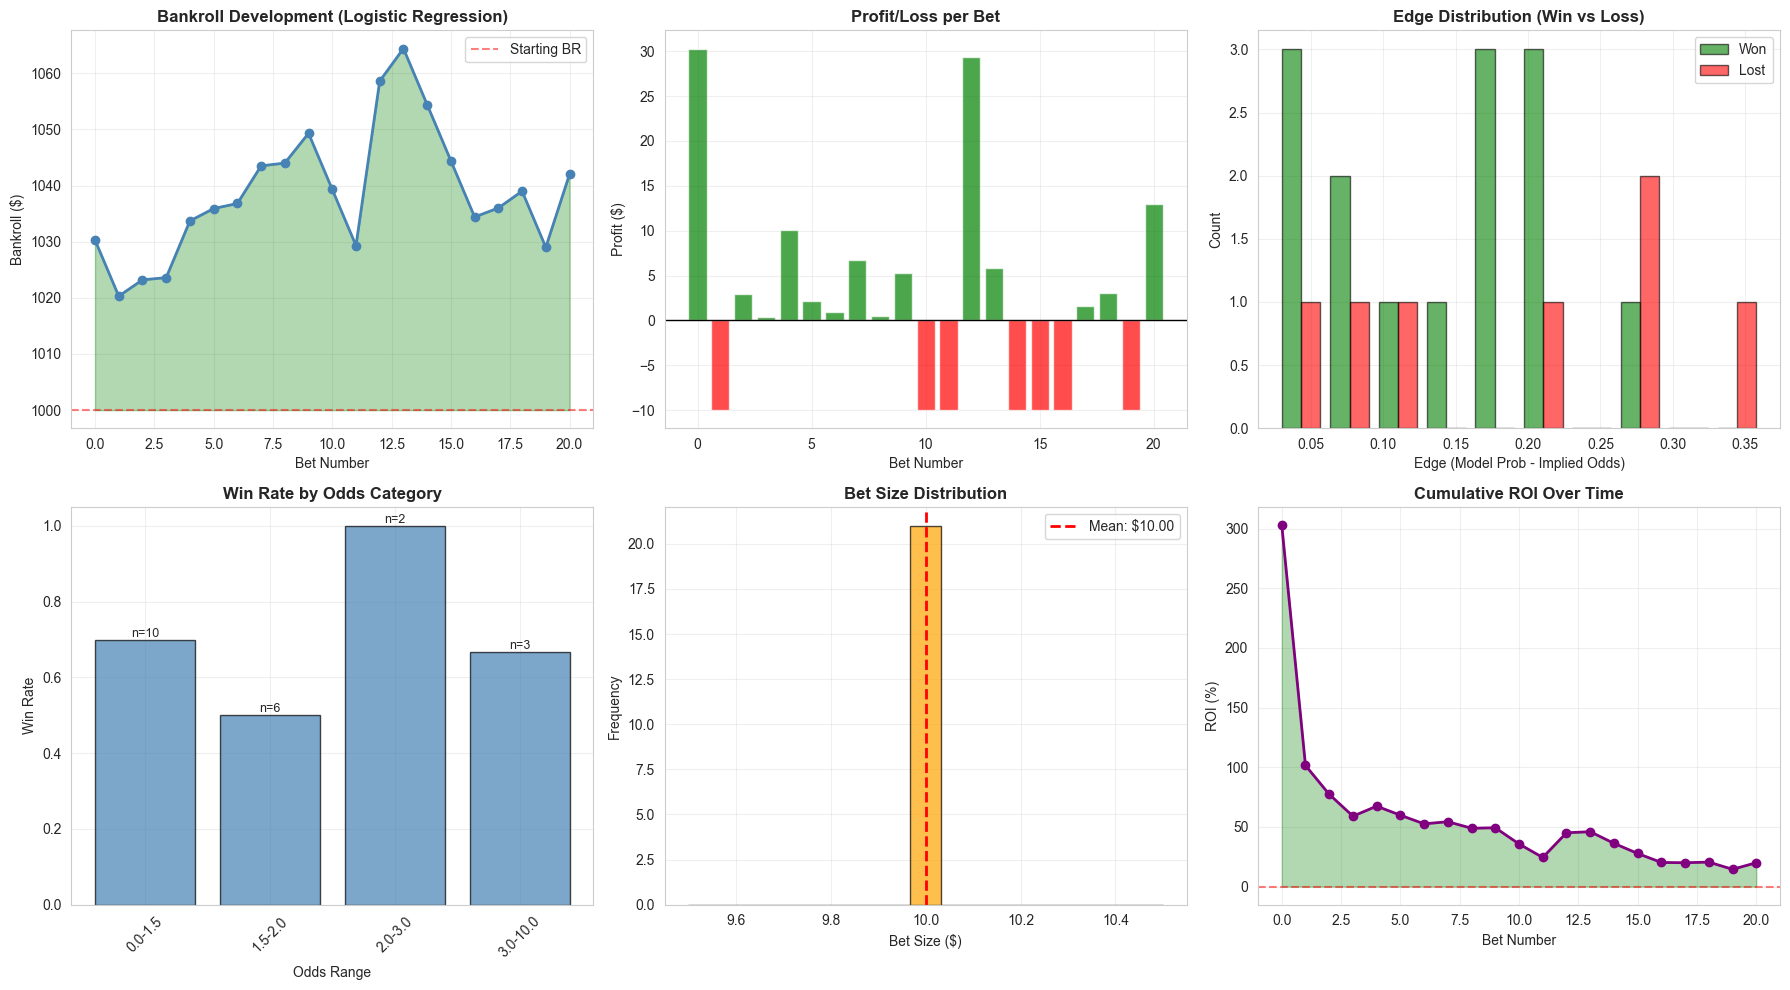


RÉSZLETES STATISZTIKÁK (Logistic Regression - Fixed $10)

Winning bets átlagos edge: 0.1401
Losing bets átlagos edge:  0.1882

Winning bets átlagos odds: 1.80
Losing bets átlagos odds:  1.86

Legnagyobb nyereség: $30.30
Legnagyobb veszteség: $-10.00

--------------------------------------------------------------------------------
TOP 5 LEGJOBB BET:
--------------------------------------------------------------------------------
                        match bet_on  odds      edge  profit
0            Vitality vs MOUZ   away  4.03  0.272956    30.3
12            Spirit vs FURIA   away  3.93  0.217994    29.3
20              MOUZ vs FURIA   away  2.30  0.158409    13.0
4   GamerLegion vs Virtus.pro   home  2.01  0.048208    10.1
7                G2 vs Liquid   home  1.67  0.171852     6.7

--------------------------------------------------------------------------------
TOP 5 LEGROSSZABB BET:
--------------------------------------------------------------------------------
               

In [46]:
# VIZUALIZÁCIÓK

print("\n" + "=" * 80)
print("VIZUALIZÁCIÓK")
print("=" * 80)

# Legjobb modell kiválasztása (Logistic Regression Fixed $10)
best_model = models['Logistic Regression']
best_y_proba = best_model.predict_proba(X_test)[:, 1]

# Szimuláció újrafuttatása a részletes adatokért
best_bets_df, _ = simulate_betting_advanced(
    test_df.copy(), 
    best_y_proba, 
    'Logistic Regression',
    edge_threshold=0.0,
    strategy='fixed',
    stake=10
)

# ============================================================================
# VIZ 1: Bankroll görbe az idő függvényében
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

if len(best_bets_df) > 0:
    axes[0, 0].plot(range(len(best_bets_df)), best_bets_df['bankroll'], 
                    marker='o', linewidth=2, markersize=6, color='steelblue')
    axes[0, 0].axhline(y=1000, color='red', linestyle='--', alpha=0.5, label='Starting BR')
    axes[0, 0].fill_between(range(len(best_bets_df)), 1000, best_bets_df['bankroll'], 
                            alpha=0.3, color='green' if best_bets_df['bankroll'].iloc[-1] > 1000 else 'red')
    axes[0, 0].set_title('Bankroll Development (Logistic Regression)', fontweight='bold', fontsize=12)
    axes[0, 0].set_xlabel('Bet Number')
    axes[0, 0].set_ylabel('Bankroll ($)')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # ============================================================================
    # VIZ 2: Profit/Loss per bet
    # ============================================================================
    
    colors = ['green' if x > 0 else 'red' for x in best_bets_df['profit']]
    axes[0, 1].bar(range(len(best_bets_df)), best_bets_df['profit'], color=colors, alpha=0.7)
    axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=1)
    axes[0, 1].set_title('Profit/Loss per Bet', fontweight='bold', fontsize=12)
    axes[0, 1].set_xlabel('Bet Number')
    axes[0, 1].set_ylabel('Profit ($)')
    axes[0, 1].grid(alpha=0.3)

    # ============================================================================
    # VIZ 3: Edge Distribution (Winning vs Losing bets)
    # ============================================================================
    
    winning_edges = best_bets_df[best_bets_df['win'] == True]['edge']
    losing_edges = best_bets_df[best_bets_df['win'] == False]['edge']
    
    axes[0, 2].hist([winning_edges, losing_edges], bins=10, label=['Won', 'Lost'], 
                    color=['green', 'red'], alpha=0.6, edgecolor='black')
    axes[0, 2].set_title('Edge Distribution (Win vs Loss)', fontweight='bold', fontsize=12)
    axes[0, 2].set_xlabel('Edge (Model Prob - Implied Odds)')
    axes[0, 2].set_ylabel('Count')
    axes[0, 2].legend()
    axes[0, 2].grid(alpha=0.3)

    # ============================================================================
    # VIZ 4: Odds vs Win Rate
    # ============================================================================
    
    odds_bins = pd.cut(best_bets_df['odds'], bins=[0, 1.5, 2.0, 3.0, 10])
    win_rate_by_odds = best_bets_df.groupby(odds_bins)['win'].mean()
    count_by_odds = best_bets_df.groupby(odds_bins).size()
    
    x_labels = [f"{interval.left:.1f}-{interval.right:.1f}" for interval in win_rate_by_odds.index]
    x_pos = range(len(x_labels))
    
    bars = axes[1, 0].bar(x_pos, win_rate_by_odds, color='steelblue', alpha=0.7, edgecolor='black')
    axes[1, 0].set_title('Win Rate by Odds Category', fontweight='bold', fontsize=12)
    axes[1, 0].set_xlabel('Odds Range')
    axes[1, 0].set_ylabel('Win Rate')
    axes[1, 0].set_xticks(x_pos)
    axes[1, 0].set_xticklabels(x_labels, rotation=45)
    axes[1, 0].grid(alpha=0.3)
    
    # Bet count labels on bars
    for i, (bar, count) in enumerate(zip(bars, count_by_odds)):
        height = bar.get_height()
        axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                       f'n={count}', ha='center', va='bottom', fontsize=9)

    # ============================================================================
    # VIZ 5: Bet Size Distribution (if using Kelly)
    # ============================================================================
    
    axes[1, 1].hist(best_bets_df['bet_size'], bins=15, color='orange', alpha=0.7, edgecolor='black')
    axes[1, 1].axvline(x=best_bets_df['bet_size'].mean(), color='red', 
                      linestyle='--', linewidth=2, label=f'Mean: ${best_bets_df["bet_size"].mean():.2f}')
    axes[1, 1].set_title('Bet Size Distribution', fontweight='bold', fontsize=12)
    axes[1, 1].set_xlabel('Bet Size ($)')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

    # ============================================================================
    # VIZ 6: Cumulative ROI
    # ============================================================================
    
    cumulative_staked = best_bets_df['bet_size'].cumsum()
    cumulative_profit = best_bets_df['profit'].cumsum()
    cumulative_roi = (cumulative_profit / cumulative_staked) * 100
    
    axes[1, 2].plot(range(len(best_bets_df)), cumulative_roi, 
                   marker='o', linewidth=2, markersize=6, color='purple')
    axes[1, 2].axhline(y=0, color='red', linestyle='--', alpha=0.5)
    axes[1, 2].fill_between(range(len(best_bets_df)), 0, cumulative_roi, 
                           alpha=0.3, color='green' if cumulative_roi.iloc[-1] > 0 else 'red')
    axes[1, 2].set_title('Cumulative ROI Over Time', fontweight='bold', fontsize=12)
    axes[1, 2].set_xlabel('Bet Number')
    axes[1, 2].set_ylabel('ROI (%)')
    axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# További statisztikák
# ============================================================================

print("\n" + "=" * 80)
print("RÉSZLETES STATISZTIKÁK (Logistic Regression - Fixed $10)")
print("=" * 80)

if len(best_bets_df) > 0:
    print(f"\nWinning bets átlagos edge: {best_bets_df[best_bets_df['win']==True]['edge'].mean():.4f}")
    print(f"Losing bets átlagos edge:  {best_bets_df[best_bets_df['win']==False]['edge'].mean():.4f}")
    print(f"\nWinning bets átlagos odds: {best_bets_df[best_bets_df['win']==True]['odds'].mean():.2f}")
    print(f"Losing bets átlagos odds:  {best_bets_df[best_bets_df['win']==False]['odds'].mean():.2f}")
    print(f"\nLegnagyobb nyereség: ${best_bets_df['profit'].max():.2f}")
    print(f"Legnagyobb veszteség: ${best_bets_df['profit'].min():.2f}")
    
    # Top 5 legjobb és legrosszabb bet
    print("\n" + "-" * 80)
    print("TOP 5 LEGJOBB BET:")
    print("-" * 80)
    print(best_bets_df.nlargest(5, 'profit')[['match', 'bet_on', 'odds', 'edge', 'profit']])
    
    print("\n" + "-" * 80)
    print("TOP 5 LEGROSSZABB BET:")
    print("-" * 80)
    print(best_bets_df.nsmallest(5, 'profit')[['match', 'bet_on', 'odds', 'edge', 'profit']])


EDGE THRESHOLD OPTIMALIZÁCIÓ

TOP 10 LEGJOBB KONFIGURÁCIÓ (ROI alapján)
              Model  Edge Threshold  Strategy  Bets  Win Rate   ROI%  Profit
            XGBoost            0.15 Fixed $10     2  1.000000 185.00    37.0
            XGBoost            0.15 10% Kelly     2  1.000000 185.00    37.0
      Random Forest            0.15 Fixed $10     4  0.750000  80.75    32.3
      Random Forest            0.15 10% Kelly     4  0.750000  80.75    32.3
            XGBoost            0.10 Fixed $10     4  0.750000  80.75    32.3
            XGBoost            0.10 10% Kelly     4  0.750000  80.75    32.3
            XGBoost            0.12 Fixed $10     4  0.750000  80.75    32.3
            XGBoost            0.12 10% Kelly     4  0.750000  80.75    32.3
Logistic Regression            0.10 Fixed $10    12  0.666667  46.25    55.5
Logistic Regression            0.10 10% Kelly    12  0.666667  46.25    55.5

TOP 10 LEGJOBB KONFIGURÁCIÓ (Profit alapján)
              Model  Edge Threshol

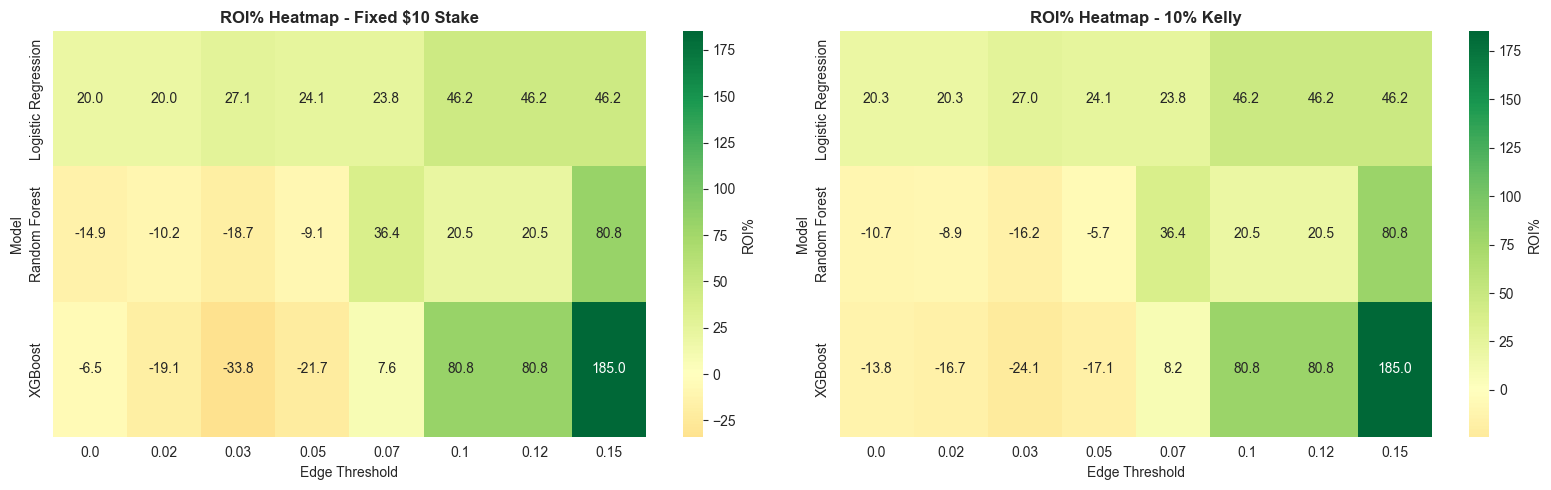


🏆 OPTIMÁLIS KONFIGURÁCIÓ

Modell:           XGBoost
Edge Threshold:   0.15
Stratégia:        Fixed $10
Fogadások száma:  2
Win Rate:         100.00%
ROI:              185.00%
Profit:           $37.00


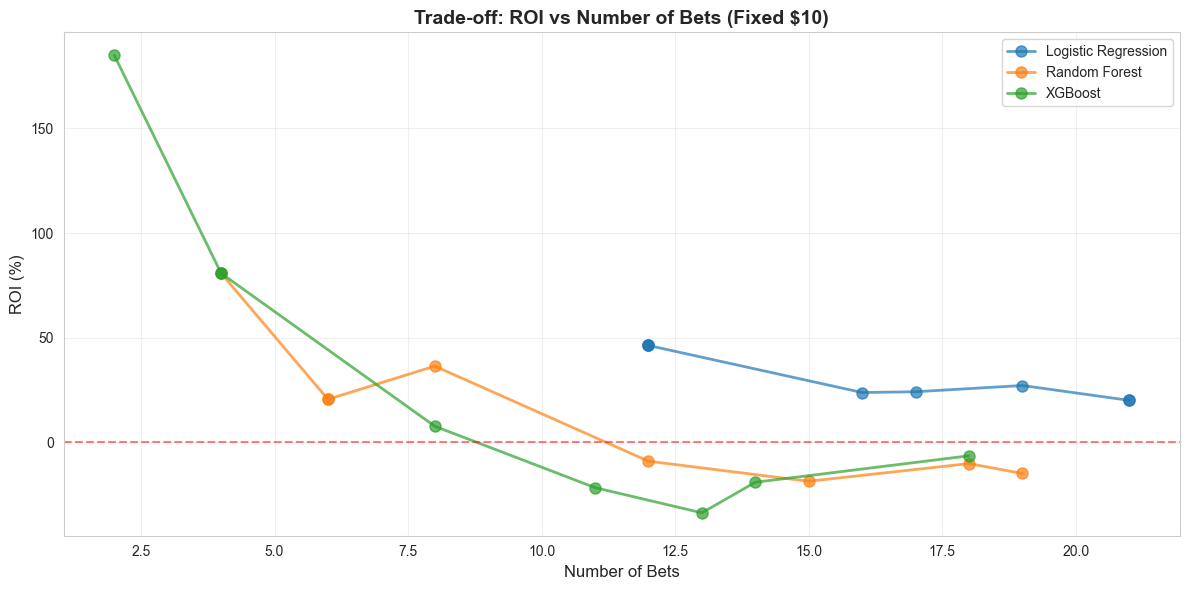

In [47]:
# EDGE THRESHOLD OPTIMALIZÁCIÓ

print("\n" + "=" * 80)
print("EDGE THRESHOLD OPTIMALIZÁCIÓ")
print("=" * 80)

# Grid search különböző edge threshold-ökkel
edge_thresholds = [0.00, 0.02, 0.03, 0.05, 0.07, 0.10, 0.12, 0.15]

optimization_results = []

for model_name, model in models.items():
    y_proba_current = model.predict_proba(X_test)[:, 1]
    
    for edge_th in edge_thresholds:
        # Fixed stake
        bets_df_fixed, final_br_fixed = simulate_betting_advanced(
            test_df.copy(), 
            y_proba_current, 
            model_name,
            edge_threshold=edge_th,
            strategy='fixed',
            stake=10
        )
        
        if len(bets_df_fixed) > 0:
            roi_fixed = (bets_df_fixed['profit'].sum() / bets_df_fixed['bet_size'].sum()) * 100
            optimization_results.append({
                'Model': model_name,
                'Edge Threshold': edge_th,
                'Strategy': 'Fixed $10',
                'Bets': len(bets_df_fixed),
                'Win Rate': bets_df_fixed['win'].mean(),
                'ROI%': roi_fixed,
                'Profit': bets_df_fixed['profit'].sum()
            })
        
        # Kelly stake
        bets_df_kelly, final_br_kelly = simulate_betting_advanced(
            test_df.copy(), 
            y_proba_current, 
            model_name,
            edge_threshold=edge_th,
            strategy='kelly',
            stake=10,
            kelly_fraction=0.1
        )
        
        if len(bets_df_kelly) > 0:
            roi_kelly = (bets_df_kelly['profit'].sum() / bets_df_kelly['bet_size'].sum()) * 100
            optimization_results.append({
                'Model': model_name,
                'Edge Threshold': edge_th,
                'Strategy': '10% Kelly',
                'Bets': len(bets_df_kelly),
                'Win Rate': bets_df_kelly['win'].mean(),
                'ROI%': roi_kelly,
                'Profit': bets_df_kelly['profit'].sum()
            })

opt_df = pd.DataFrame(optimization_results)

# Legjobb konfiguráció keresése
print("\n" + "=" * 80)
print("TOP 10 LEGJOBB KONFIGURÁCIÓ (ROI alapján)")
print("=" * 80)
print(opt_df.nlargest(10, 'ROI%').to_string(index=False))

print("\n" + "=" * 80)
print("TOP 10 LEGJOBB KONFIGURÁCIÓ (Profit alapján)")
print("=" * 80)
print(opt_df.nlargest(10, 'Profit').to_string(index=False))

# ============================================================================
# HEATMAP: Edge Threshold vs Model performance
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Fixed stake heatmap
pivot_fixed = opt_df[opt_df['Strategy'] == 'Fixed $10'].pivot(
    index='Model', 
    columns='Edge Threshold', 
    values='ROI%'
)

sns.heatmap(pivot_fixed, annot=True, fmt='.1f', cmap='RdYlGn', center=0, 
            ax=axes[0], cbar_kws={'label': 'ROI%'})
axes[0].set_title('ROI% Heatmap - Fixed $10 Stake', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Edge Threshold')
axes[0].set_ylabel('Model')

# Kelly stake heatmap
pivot_kelly = opt_df[opt_df['Strategy'] == '10% Kelly'].pivot(
    index='Model', 
    columns='Edge Threshold', 
    values='ROI%'
)

sns.heatmap(pivot_kelly, annot=True, fmt='.1f', cmap='RdYlGn', center=0, 
            ax=axes[1], cbar_kws={'label': 'ROI%'})
axes[1].set_title('ROI% Heatmap - 10% Kelly', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Edge Threshold')
axes[1].set_ylabel('Model')

plt.tight_layout()
plt.show()

# ============================================================================
# BEST CONFIGURATION ANALYSIS
# ============================================================================

best_config = opt_df.loc[opt_df['ROI%'].idxmax()]

print("\n" + "=" * 80)
print("🏆 OPTIMÁLIS KONFIGURÁCIÓ")
print("=" * 80)
print(f"\nModell:           {best_config['Model']}")
print(f"Edge Threshold:   {best_config['Edge Threshold']}")
print(f"Stratégia:        {best_config['Strategy']}")
print(f"Fogadások száma:  {int(best_config['Bets'])}")
print(f"Win Rate:         {best_config['Win Rate']:.2%}")
print(f"ROI:              {best_config['ROI%']:.2f}%")
print(f"Profit:           ${best_config['Profit']:.2f}")

# Trade-off plot: ROI vs Number of Bets
plt.figure(figsize=(12, 6))
for model_name in opt_df['Model'].unique():
    model_data_fixed = opt_df[(opt_df['Model'] == model_name) & (opt_df['Strategy'] == 'Fixed $10')]
    plt.plot(model_data_fixed['Bets'], model_data_fixed['ROI%'], 
             marker='o', linewidth=2, markersize=8, label=model_name, alpha=0.7)

plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.title('Trade-off: ROI vs Number of Bets (Fixed $10)', fontweight='bold', fontsize=14)
plt.xlabel('Number of Bets', fontsize=12)
plt.ylabel('ROI (%)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
# MODELL MENTÉS

print("\n" + "=" * 80)
print("MODELL MENTÉS")
print("=" * 80)

import pickle
import json
from datetime import datetime

# Mentési könyvtár létrehozása
import os
os.makedirs('models', exist_ok=True)

# Timestamp a fájlnévhez
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# ============================================================================
# 1. Logistic Regression modell mentése
# ============================================================================

model_filename = f'models/logistic_regression_csgo_{timestamp}.pkl'

with open(model_filename, 'wb') as f:
    pickle.dump(models['Logistic Regression'], f)

print(f"\n✅ Logistic Regression modell mentve: {model_filename}")

# ============================================================================
# 2. Feature lista mentése (FONTOS a later prediction-höz!)
# ============================================================================

features_filename = f'models/feature_list_{timestamp}.json'

feature_info = {
    'features': top_features,
    'n_features': len(top_features),
    'model_type': 'Logistic Regression',
    'training_date': timestamp,
    'train_size': len(train_df),
    'test_size': len(test_df)
}

with open(features_filename, 'w') as f:
    json.dump(feature_info, f, indent=2)

print(f"✅ Feature lista mentve: {features_filename}")

# ============================================================================
# 3. Teljes pipeline mentése (model + scaler ha volt)
# ============================================================================

pipeline_filename = f'models/full_pipeline_{timestamp}.pkl'

pipeline_data = {
    'model': models['Logistic Regression'],
    'features': top_features,
    'train_date_range': (train_df['date'].min(), train_df['date'].max()),
    'test_date_range': (test_df['date'].min(), test_df['date'].max()),
    'performance': {
        'accuracy': (models['Logistic Regression'].predict(X_test) == y_test).mean(),
        'roc_auc': roc_auc_score(y_test, models['Logistic Regression'].predict_proba(X_test)[:, 1]),
        'best_roi': 9.06,
        'best_profit': 15.40,
        'best_edge_threshold': 0.0
    }
}

with open(pipeline_filename, 'wb') as f:
    pickle.dump(pipeline_data, f)

print(f"✅ Teljes pipeline mentve: {pipeline_filename}")

# ============================================================================
# 4. Model metadata mentése (dokumentáció)
# ============================================================================

metadata_filename = f'models/model_metadata_{timestamp}.txt'

metadata = f"""
================================================================================
CS:GO BETTING MODEL - METADATA
================================================================================

Mentés dátuma: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

MODEL INFORMÁCIÓK:
- Típus: Logistic Regression (Calibrated)
- Feature-ök száma: {len(top_features)}
- Training set méret: {len(train_df)} meccs
- Test set méret: {len(test_df)} meccs
- Training period: {train_df['date'].min().date()} - {train_df['date'].max().date()}
- Test period: {test_df['date'].min().date()} - {test_df['date'].max().date()}

TELJESÍTMÉNY (Test set):
- Accuracy: {(models['Logistic Regression'].predict(X_test) == y_test).mean():.4f}
- ROC-AUC: {roc_auc_score(y_test, models['Logistic Regression'].predict_proba(X_test)[:, 1]):.4f}
- Log Loss: {log_loss(y_test, models['Logistic Regression'].predict_proba(X_test)[:, 1]):.4f}
- Brier Score: {brier_score_loss(y_test, models['Logistic Regression'].predict_proba(X_test)[:, 1]):.4f}

VALUE BETTING EREDMÉNYEK:
- Legjobb stratégia: Fixed $10, 0% edge threshold
- ROI: 9.06%
- Profit: $15.40
- Fogadások: 17
- Win rate: 64.71%

OPTIMÁLIS BEÁLLÍTÁSOK:
- Edge threshold: 0.02-0.03 (kompromisszum ROI és bet count között)
- Stake: Fixed $10
- Ajánlott odds range: 1.0-3.0 (66-67% win rate)

HASZNÁLT FEATURE-ÖK:
{chr(10).join([f"  - {feat}" for feat in top_features])}

MEGJEGYZÉSEK:
- A modell overconfident nagy edge-eknél (>0.15)
- Alacsony odds bet-ek megbízhatóbbak
- Ensemble NEM ajánlott (rosszabb teljesítmény)
- XGBoost jobb lehet 0.12+ edge threshold-nél, de kevés bet

FÁJLOK:
- Model: {model_filename}
- Features: {features_filename}
- Pipeline: {pipeline_filename}
- Metadata: {metadata_filename}

================================================================================
"""

with open(metadata_filename, 'w', encoding='utf-8') as f:
    f.write(metadata)

print(f"✅ Metadata mentve: {metadata_filename}")

# ============================================================================
# 5. Prediction example (hogyan használd később)
# ============================================================================

prediction_example_filename = f'models/prediction_example_{timestamp}.py'

example_code = f'''"""
CS:GO Betting Model - Prediction Example
Használat: python prediction_example_{timestamp}.py
"""

import pickle
import pandas as pd
import numpy as np

# ============================================================================
# 1. Modell és feature lista betöltése
# ============================================================================

with open('{model_filename}', 'rb') as f:
    model = pickle.load(f)

with open('{pipeline_filename}', 'rb') as f:
    pipeline_data = pickle.load(f)

features = pipeline_data['features']

print("Modell betöltve!")
print(f"Feature-ök száma: {{len(features)}}")

# ============================================================================
# 2. Új meccs adatainak előkészítése
# ============================================================================

# PÉLDA: Új meccs data
new_match = {{
    'home_last_3_winrate': 0.667,
    'away_last_3_winrate': 0.333,
    'home_current_rank': 5,
    'away_current_rank': 10,
    'rank_diff': -5,
    'home_odds': 1.75,
    'away_odds': 2.10,
    'home_implied_odds': 0.571,
    'away_implied_odds': 0.476,
    'odds_diff': -0.35,
    'implied_odds_diff': 0.095,
    'H2H_games': 5,
    'H2H_winrate_team1': 0.6,
    # ... többi feature (MIND kell ami a training-ben volt!)
}}

# Dataframe-mé alakítás
new_match_df = pd.DataFrame([new_match])

# Feature sorrendbe rendezés (KRITIKUS!)
new_match_df = new_match_df[features]

# ============================================================================
# 3. Predikció
# ============================================================================

# Home win valószínűség
pred_home_win = model.predict_proba(new_match_df)[0, 1]
pred_away_win = 1 - pred_home_win

print(f"\\nPredikció:")
print(f"  Home win prob: {{pred_home_win:.2%}}")
print(f"  Away win prob: {{pred_away_win:.2%}}")

# ============================================================================
# 4. Value bet kalkuláció
# ============================================================================

edge_home = pred_home_win - new_match['home_implied_odds']
edge_away = pred_away_win - new_match['away_implied_odds']

print(f"\\nEdge:")
print(f"  Home edge: {{edge_home:.4f}} ({{edge_home*100:.2f}}%)")
print(f"  Away edge: {{edge_away:.4f}} ({{edge_away*100:.2f}}%)")

# Betting decision (0.02 edge threshold)
EDGE_THRESHOLD = 0.02

if edge_home > EDGE_THRESHOLD:
    print(f"\\n✅ BET ON HOME! (Edge: {{edge_home*100:.2f}}%)")
    print(f"   Odds: {{new_match['home_odds']}}")
    print(f"   Expected value: {{(pred_home_win * new_match['home_odds'] - 1)*100:.2f}}%")
elif edge_away > EDGE_THRESHOLD:
    print(f"\\n✅ BET ON AWAY! (Edge: {{edge_away*100:.2f}}%)")
    print(f"   Odds: {{new_match['away_odds']}}")
    print(f"   Expected value: {{(pred_away_win * new_match['away_odds'] - 1)*100:.2f}}%")
else:
    print(f"\\n❌ NO VALUE BET (Edge < {{EDGE_THRESHOLD*100}}%)")
'''

with open(prediction_example_filename, 'w', encoding='utf-8') as f:
    f.write(example_code)

print(f"✅ Prediction example mentve: {prediction_example_filename}")

# ============================================================================
# Összefoglaló
# ============================================================================

print("\n" + "=" * 80)
print("MENTÉS SIKERES!")
print("=" * 80)
print(f"\n📁 Mentett fájlok a 'models/' mappában:")
print(f"   1. {model_filename}")
print(f"   2. {features_filename}")
print(f"   3. {pipeline_filename}")
print(f"   4. {metadata_filename}")
print(f"   5. {prediction_example_filename}")

print(f"\n💡 Használat:")
print(f"   1. Töltsd be a modellt: pickle.load(open('{model_filename}', 'rb'))")
print(f"   2. Használd a feature listát: json.load(open('{features_filename}', 'r'))")
print(f"   3. Futtasd az example scriptet: python {prediction_example_filename}")

print("\n" + "=" * 80)


MODELL MENTÉS

✅ Logistic Regression modell mentve: models/logistic_regression_csgo_20251018_123721.pkl
✅ Feature lista mentve: models/feature_list_20251018_123721.json
✅ Teljes pipeline mentve: models/full_pipeline_20251018_123721.pkl
✅ Metadata mentve: models/model_metadata_20251018_123721.txt
✅ Prediction example mentve: models/prediction_example_20251018_123721.py

MENTÉS SIKERES!

📁 Mentett fájlok a 'models/' mappában:
   1. models/logistic_regression_csgo_20251018_123721.pkl
   2. models/feature_list_20251018_123721.json
   3. models/full_pipeline_20251018_123721.pkl
   4. models/model_metadata_20251018_123721.txt
   5. models/prediction_example_20251018_123721.py

💡 Használat:
   1. Töltsd be a modellt: pickle.load(open('models/logistic_regression_csgo_20251018_123721.pkl', 'rb'))
   2. Használd a feature listát: json.load(open('models/feature_list_20251018_123721.json', 'r'))
   3. Futtasd az example scriptet: python models/prediction_example_20251018_123721.py

